# Modelo de Severidad en Urgencias — v3

## 5 Niveles de Severidad · 3 Horizontes de Prediccion (+1h, +3h, +6h)

**Objetivo:** Reemplazar el semaforo de 3 niveles (Verde/Amarillo/Rojo) por un sistema de
**5 niveles de severidad operativa** con prediccion independiente para cada horizonte.

### Cambios respecto a v2
| Aspecto | v2 | v3 |
|---|---|---|
| Niveles | 3 (Verde/Amarillo/Rojo) | 5 (Verde_Am / Pres_Mod / Pres_Alta / Critico / Colapso) |
| Modelos | 1 RF para proyeccion multi-step | 3 RF independientes (uno por horizonte) |
| Encoding hora | valor entero 0-23 | seno + coseno (ciclico) |
| Encoding dia | entero 0-6 | seno + coseno (ciclico) |
| Presion sistema | no existia | cola + camas como feature |
| Validacion | train/test simple | TimeSeriesSplit 5 folds |
| Metrica principal | RMSE / R2 | MASE + Balanced Accuracy + F1-macro |


In [1]:

import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


In [2]:

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_PATH = os.path.join(BASE_DIR, "data", "dataset_train.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")
NOTEBOOK_DIR = os.path.join(BASE_DIR, "notebooks")
os.makedirs(MODEL_DIR, exist_ok=True)
print("OK")


OK


In [3]:

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
print(f"Filas: {len(df):,}")
print(f"Periodo: {df['datetime'].min()} -> {df['datetime'].max()}")
print(f"Columnas: {list(df.columns)}")


Filas: 20,667
Periodo: 2024-01-01 06:00:00 -> 2026-05-29 23:00:00
Columnas: ['cant_triage', 'cola_esperando_inicio_hora', 'camas_ocupadas', 'abandonos_triage', 'capacidad_hora', 'cant_triage_lag1h', 'cant_triage_lag2h', 'cant_triage_lag3h', 'saturacion_lag1h', 'saturacion_lag3h', 'saturacion_lag6h', 'abandonos_lag1h', 'cola_lag1h', 'camas_ocupadas_lag1h', 'tiempo_turnero_min', 'pct_cumpl_oportunidad_triage', 'pct_cumpl_consulta_t2', 'tiempo_consulta_min', 'hora', 'dia_semana_enc', 'es_festivo', 'saturacion_idx', 'datetime', 'nivel_saturacion']


## 1. Analisis exploratorio de saturacion

In [4]:

print("Estadisticas de saturacion_idx:")
print(df["saturacion_idx"].describe())
print()
print("Percentiles clave:")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:2d}: {df['saturacion_idx'].quantile(p/100):.4f}")


Estadisticas de saturacion_idx:
count    20667.000000
mean         2.250886
std          0.767730
min          0.208300
25%          1.666700
50%          2.250000
75%          2.791700
max          4.700000
Name: saturacion_idx, dtype: float64

Percentiles clave:
  P 5: 1.0417
  P10: 1.2083
  P25: 1.6667
  P50: 2.2500
  P75: 2.7917
  P90: 3.2500
  P95: 3.5500
  P99: 4.0833


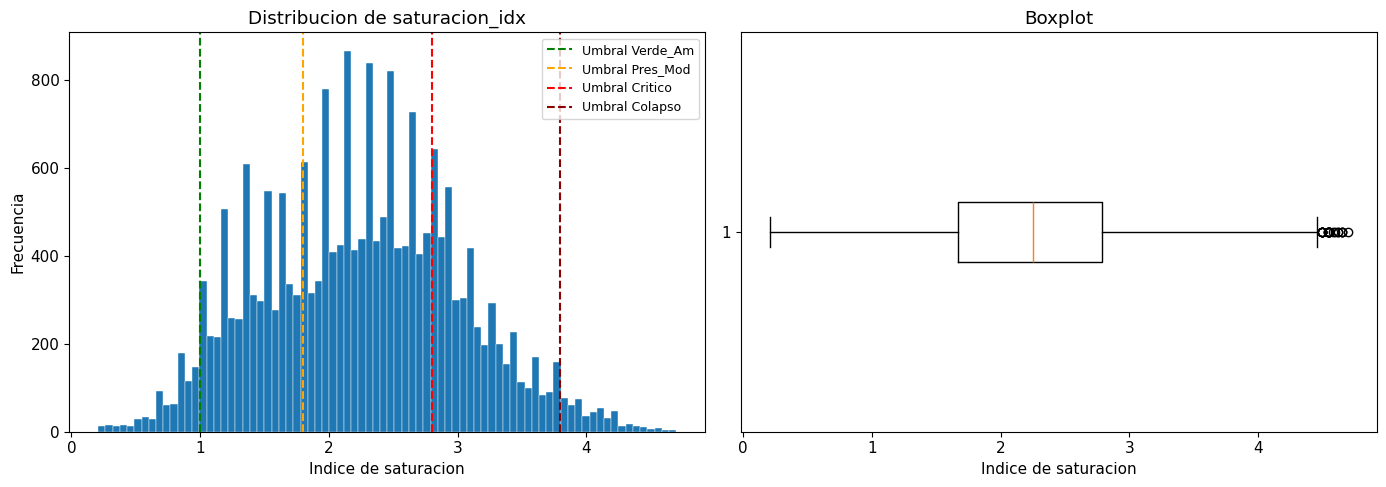

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["saturacion_idx"], bins=80, color="#1f77b4", edgecolor="white", linewidth=0.3)
axes[0].axvline(1.0, color="green", ls="--", lw=1.5, label="Umbral Verde_Am")
axes[0].axvline(1.8, color="orange", ls="--", lw=1.5, label="Umbral Pres_Mod")
axes[0].axvline(2.8, color="red", ls="--", lw=1.5, label="Umbral Critico")
axes[0].axvline(3.8, color="darkred", ls="--", lw=1.5, label="Umbral Colapso")
axes[0].set_xlabel("Indice de saturacion")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de saturacion_idx")
axes[0].legend(fontsize=9)
axes[1].boxplot(df["saturacion_idx"], vert=False)
axes[1].set_xlabel("Indice de saturacion")
axes[1].set_title("Boxplot")
plt.tight_layout()
plt.show()


## 2. Definicion de los 5 niveles de severidad

Los umbrales se basan en la distribucion real del dataset:

| Nivel | Rango | % esperado | Accion |
|---|---|---|---|
| Verde_Amarillo | < 1.0 | ~4% | Operacion normal |
| Presion_Moderada | 1.0 - 1.8 | ~26% | Monitorear |
| Presion_Alta | 1.8 - 2.8 | ~47% | Preparar refuerzos |
| Critico | 2.8 - 3.8 | ~21% | Activar contingencia |
| Colapso | > 3.8 | ~3% | Protocolo de colapso |


In [6]:

UMBRALES = [1.0, 1.8, 2.8, 3.8]
NIVELES = ["Verde_Amarillo", "Presion_Moderada", "Presion_Alta", "Critico", "Colapso"]
COLORES = {"Verde_Amarillo": "#28a745", "Presion_Moderada": "#ffc107",
           "Presion_Alta": "#fd7e14", "Critico": "#dc3545", "Colapso": "#6f42c1"}

def clasificar_severidad(valor):
    if valor < UMBRALES[0]:
        return "Verde_Amarillo"
    elif valor < UMBRALES[1]:
        return "Presion_Moderada"
    elif valor < UMBRALES[2]:
        return "Presion_Alta"
    elif valor < UMBRALES[3]:
        return "Critico"
    else:
        return "Colapso"

df["severidad"] = df["saturacion_idx"].apply(clasificar_severidad)
print("Distribucion de niveles de severidad:")
print(df["severidad"].value_counts())
print()
print("% del total:")
print(df["severidad"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


Distribucion de niveles de severidad:
severidad
Presion_Alta        9634
Presion_Moderada    5312
Critico             4377
Verde_Amarillo       817
Colapso              527
Name: count, dtype: int64

% del total:
severidad
Presion_Alta        46.6%
Presion_Moderada    25.7%
Critico             21.2%
Verde_Amarillo       4.0%
Colapso              2.5%
Name: proportion, dtype: str


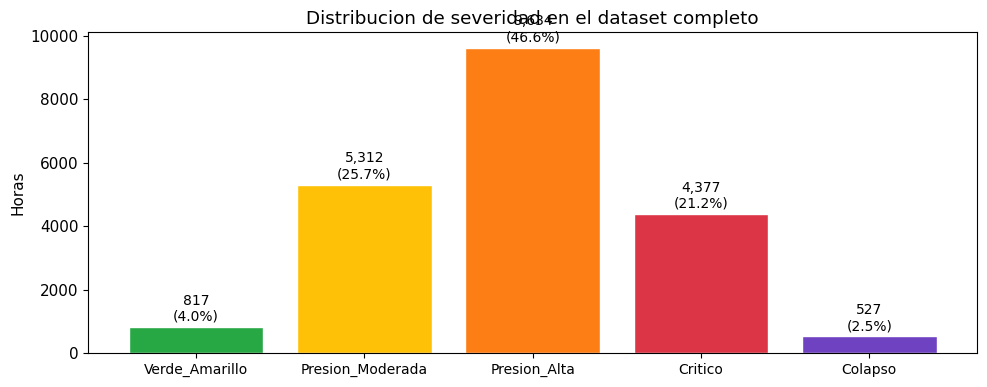

In [7]:

fig, ax = plt.subplots(figsize=(10, 4))
colores_lista = [COLORES[n] for n in NIVELES]
counts = df["severidad"].value_counts()
bars = ax.bar(range(len(NIVELES)), [counts.get(n, 0) for n in NIVELES], color=colores_lista, edgecolor="white")
for bar, label in zip(bars, [f"{counts.get(n, 0):,}\n({counts.get(n, 0)/len(df)*100:.1f}%)" for n in NIVELES]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, label, ha="center", fontsize=10)
ax.set_xticks(range(len(NIVELES)))
ax.set_xticklabels(NIVELES, fontsize=10)
ax.set_ylabel("Horas")
ax.set_title("Distribucion de severidad en el dataset completo")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

### Encoding ciclico para hora y dia
Usamos seno/coseno para evitar el salto artificial entre 23h -> 0h.

### Presion combinada del sistema
Agregamos `cola + camas_ocupadas` como senal unificada de tension.


In [8]:

# Encoding ciclico de hora
df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

# Encoding ciclico de dia
df["dia_sin"] = np.sin(2 * np.pi * df["dia_semana_enc"] / 7)
df["dia_cos"] = np.cos(2 * np.pi * df["dia_semana_enc"] / 7)

# Presion combinada del sistema
df["presion_sistema"] = df["cola_esperando_inicio_hora"] + df["camas_ocupadas"]

# Verificar que no hay NA
print(f"NA despues de feature engineering: {df.isna().sum().sum()}")
print(f"Total columnas: {len(df.columns)}")
print(f"Shape: {df.shape}")


NA despues de feature engineering: 0
Total columnas: 30
Shape: (20667, 30)


## 4. Creacion de targets para 3 horizontes

Creamos variables target desplazadas: `saturacion_idx_t+1h`, `saturacion_idx_t+3h`, `saturacion_idx_t+6h`.

Esto nos permite entrenar **3 modelos independientes**, uno por horizonte.


In [9]:

HORIZONTES = {"1h": 1, "3h": 3, "6h": 6}
for nombre, horas in HORIZONTES.items():
    df[f"target_{nombre}"] = df["saturacion_idx"].shift(-horas)

# Eliminar filas donde el target es NA (no hay futuro)
df_model = df.dropna(subset=[f"target_{h}" for h in HORIZONTES]).copy()
print(f"Filas con target disponible: {len(df_model):,} (de {len(df):,})")
print(f"Rango de fechas: {df_model['datetime'].min()} -> {df_model['datetime'].max()}")


Filas con target disponible: 20,661 (de 20,667)
Rango de fechas: 2024-01-01 06:00:00 -> 2026-05-29 17:00:00


## 5. Features definitivas

Lista completa de predictores que usaremos:


In [10]:

BASE_FEATURES = [
    "cant_triage", "cola_esperando_inicio_hora", "camas_ocupadas",
    "abandonos_triage", "capacidad_hora",
    "cant_triage_lag1h", "cant_triage_lag2h", "cant_triage_lag3h",
    "saturacion_lag1h", "saturacion_lag3h", "saturacion_lag6h",
    "abandonos_lag1h", "cola_lag1h", "camas_ocupadas_lag1h",
    "tiempo_turnero_min", "pct_cumpl_oportunidad_triage",
    "pct_cumpl_consulta_t2", "tiempo_consulta_min",
    "es_festivo",
]

# Features nuevas
CICLICAS = ["hora_sin", "hora_cos", "dia_sin", "dia_cos"]
COMPUESTAS = ["presion_sistema"]

FEATURES = BASE_FEATURES + CICLICAS + COMPUESTAS
print(f"Total features: {len(FEATURES)}")
print("Features:", FEATURES)


Total features: 24
Features: ['cant_triage', 'cola_esperando_inicio_hora', 'camas_ocupadas', 'abandonos_triage', 'capacidad_hora', 'cant_triage_lag1h', 'cant_triage_lag2h', 'cant_triage_lag3h', 'saturacion_lag1h', 'saturacion_lag3h', 'saturacion_lag6h', 'abandonos_lag1h', 'cola_lag1h', 'camas_ocupadas_lag1h', 'tiempo_turnero_min', 'pct_cumpl_oportunidad_triage', 'pct_cumpl_consulta_t2', 'tiempo_consulta_min', 'es_festivo', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'presion_sistema']


## 6. Validacion cruzada temporal

Usamos `TimeSeriesSplit` con 5 folds (sin shuffle) para respetar el orden temporal.


In [11]:

tscv = TimeSeriesSplit(n_splits=5, gap=0)

X = df_model[FEATURES]
y_dict = {h: df_model[f"target_{h}"] for h in HORIZONTES}

print(f"X shape: {X.shape}")
print(f"TimeSeriesSplit folds: {tscv.n_splits}")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    train_pct = len(train_idx) / len(X) * 100
    print(f"  Fold {fold+1}: train={len(train_idx):,} ({train_pct:.0f}%), val={len(val_idx):,}")


X shape: (20661, 24)
TimeSeriesSplit folds: 5
  Fold 1: train=3,446 (17%), val=3,443
  Fold 2: train=6,889 (33%), val=3,443
  Fold 3: train=10,332 (50%), val=3,443
  Fold 4: train=13,775 (67%), val=3,443
  Fold 5: train=17,218 (83%), val=3,443


## 7. Entrenamiento de los 3 modelos

Entrenamos un Random Forest por horizonte con validacion cruzada temporal.


In [12]:

modelos = {}
metricas_cv = []

for nombre, horas in HORIZONTES.items():
    print(f"\n{'='*60}")
    print(f"Entrenando modelo +{nombre}")
    print(f"{'='*60}")
    y = y_dict[nombre]

    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        rf = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            n_jobs=-1, random_state=42 + fold
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)

        # MASE: escala contra naive (persistencia)
        y_naive = y_val.shift(1).fillna(y_val.iloc[0])
        mae_naive = mean_absolute_error(y_val, y_naive)
        mase = mae / mae_naive if mae_naive > 0 else np.nan

        fold_scores.append({"fold": fold+1, "MAE": mae, "RMSE": rmse, "R2": r2, "MASE": mase})
        print(f"  Fold {fold+1}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}, MASE={mase:.4f}")

    # Entrenar modelo final con todos los datos
    rf_final = RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=42
    )
    rf_final.fit(X, y)

    modelos[nombre] = rf_final

    # Metricas promedio CV
    avg = {k: np.mean([s[k] for s in fold_scores]) for k in ["MAE", "RMSE", "R2", "MASE"]}
    metricas_cv.append({"horizonte": nombre, **avg})
    print(f"  >> PROMEDIO CV: MAE={avg['MAE']:.4f}, RMSE={avg['RMSE']:.4f}, R2={avg['R2']:.4f}, MASE={avg['MASE']:.4f}")

df_metricas = pd.DataFrame(metricas_cv)
print(f"\n{'='*60}")
print("RESUMEN CV - 3 MODELOS")
print(df_metricas.to_string(index=False))



Entrenando modelo +1h
  Fold 1: MAE=0.0708, RMSE=0.0935, R2=0.9726, MASE=0.9194
  Fold 2: MAE=0.0728, RMSE=0.0968, R2=0.9776, MASE=1.0450
  Fold 3: MAE=0.1131, RMSE=0.1580, R2=0.9663, MASE=1.0114
  Fold 4: MAE=0.1126, RMSE=0.1545, R2=0.9559, MASE=0.9080
  Fold 5: MAE=0.4372, RMSE=0.4720, R2=0.5264, MASE=3.4562
  >> PROMEDIO CV: MAE=0.1613, RMSE=0.1950, R2=0.8797, MASE=1.4680

Entrenando modelo +3h
  Fold 1: MAE=0.1288, RMSE=0.1657, R2=0.9139, MASE=1.6729
  Fold 2: MAE=0.1331, RMSE=0.1736, R2=0.9280, MASE=1.9078
  Fold 3: MAE=0.2085, RMSE=0.2774, R2=0.8961, MASE=1.8652
  Fold 4: MAE=0.1871, RMSE=0.2437, R2=0.8904, MASE=1.5085
  Fold 5: MAE=0.4308, RMSE=0.4888, R2=0.4914, MASE=3.4042
  >> PROMEDIO CV: MAE=0.2177, RMSE=0.2698, R2=0.8240, MASE=2.0717

Entrenando modelo +6h
  Fold 1: MAE=0.1836, RMSE=0.2364, R2=0.8249, MASE=2.3850
  Fold 2: MAE=0.1923, RMSE=0.2459, R2=0.8555, MASE=2.7594
  Fold 3: MAE=0.2899, RMSE=0.3746, R2=0.8106, MASE=2.5940
  Fold 4: MAE=0.2540, RMSE=0.3202, R2=0.8109,

## 8. Evaluacion por severidad (clasificacion)

Calculamos Balanced Accuracy y F1-macro para cada modelo.


In [13]:

from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report

# Usar ultimo fold como test holdout (el mas reciente en el tiempo)
_, test_idx = list(tscv.split(X))[-1]
X_test = X.iloc[test_idx]

for nombre, horas in HORIZONTES.items():
    y_test = y_dict[nombre].iloc[test_idx]
    y_pred = modelos[nombre].predict(X_test)

    y_test_cls = [clasificar_severidad(v) for v in y_test]
    y_pred_cls = [clasificar_severidad(v) for v in y_pred]

    ba = balanced_accuracy_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls, average="macro")

    print(f"\n{'='*60}")
    print(f"Modelo +{nombre} — Clasificacion en test")
    print(f"Balanced Accuracy: {ba:.4f}")
    print(f"F1-macro: {f1:.4f}")
    print()
    print(classification_report(y_test_cls, y_pred_cls, labels=NIVELES, digits=3))



Modelo +1h — Clasificacion en test
Balanced Accuracy: 0.8798
F1-macro: 0.8881

                  precision    recall  f1-score   support

  Verde_Amarillo      0.844     0.871     0.857        31
Presion_Moderada      0.889     0.911     0.900       326
    Presion_Alta      0.897     0.938     0.917      1506
         Critico      0.923     0.893     0.907      1379
         Colapso      0.946     0.786     0.859       201

        accuracy                          0.908      3443
       macro avg      0.900     0.880     0.888      3443
    weighted avg      0.909     0.908     0.908      3443


Modelo +3h — Clasificacion en test
Balanced Accuracy: 0.7806
F1-macro: 0.8180

                  precision    recall  f1-score   support

  Verde_Amarillo      0.850     0.548     0.667        31
Presion_Moderada      0.839     0.836     0.838       324
    Presion_Alta      0.855     0.900     0.877      1506
         Critico      0.880     0.862     0.871      1381
         Colapso      0.

### Matrices de confusion normalizadas (recall por clase)

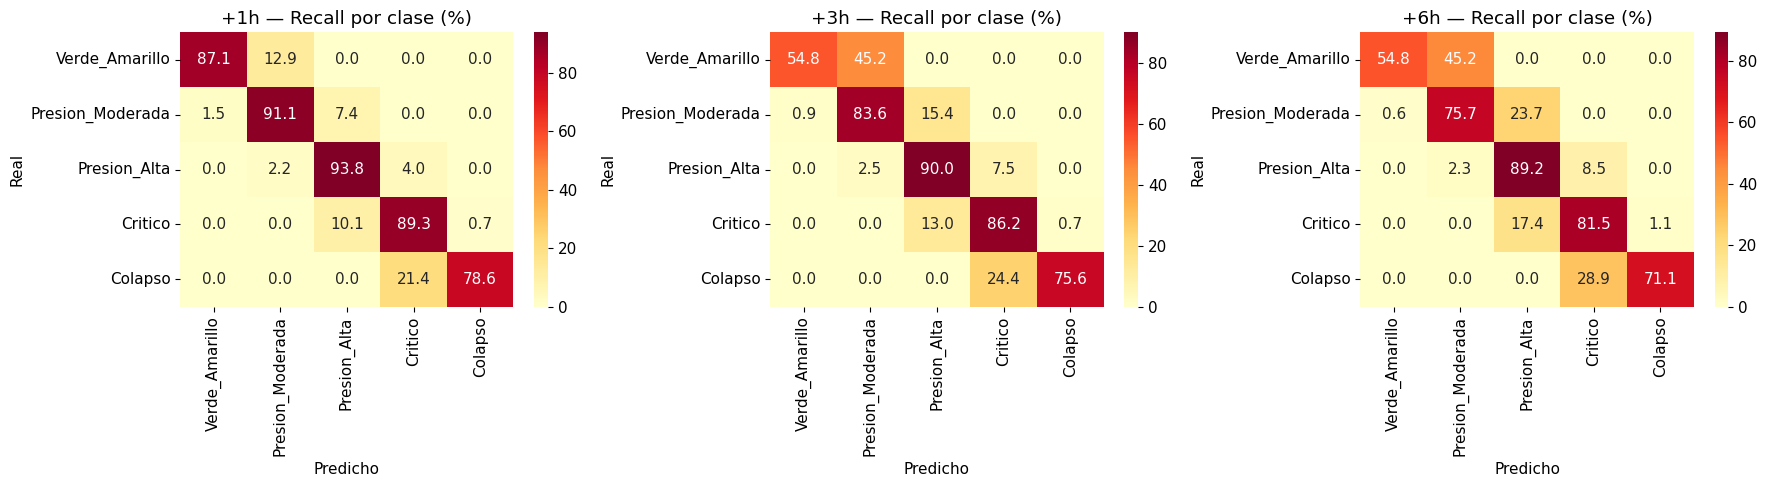

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (nombre, horas) in enumerate(HORIZONTES.items()):
    y_test = y_dict[nombre].iloc[test_idx]
    y_pred = modelos[nombre].predict(X_test)
    y_test_cls = [clasificar_severidad(v) for v in y_test]
    y_pred_cls = [clasificar_severidad(v) for v in y_pred]

    cm = confusion_matrix(y_test_cls, y_pred_cls, labels=NIVELES)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="YlOrRd",
                xticklabels=NIVELES, yticklabels=NIVELES, ax=axes[idx])
    axes[idx].set_title(f"+{nombre} — Recall por clase (%)")
    axes[idx].set_xlabel("Predicho")
    axes[idx].set_ylabel("Real")

plt.tight_layout()
plt.show()


## 9. Importancia de features

Analizamos los predictores mas relevantes para cada horizonte.


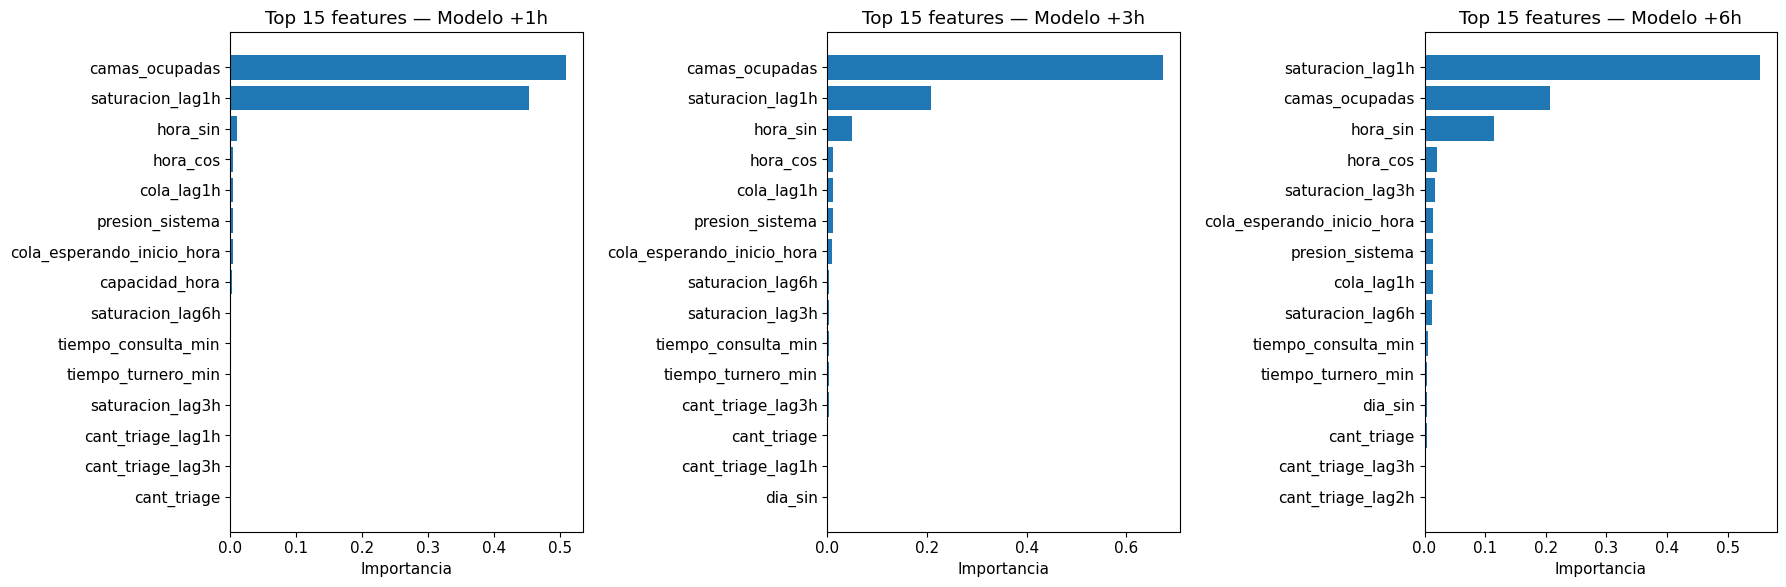

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (nombre, horas) in enumerate(HORIZONTES.items()):
    fi = pd.DataFrame({"feature": FEATURES, "importancia": modelos[nombre].feature_importances_})
    fi = fi.sort_values("importancia", ascending=True).tail(15)

    axes[idx].barh(fi["feature"], fi["importancia"], color="#1f77b4")
    axes[idx].set_title(f"Top 15 features — Modelo +{nombre}")
    axes[idx].set_xlabel("Importancia")

plt.tight_layout()
plt.show()


## 10. Simulacion operativa

Generamos prediccion para los 3 horizontes con el estado actual del sistema.


In [16]:

def predecir_3_horizontes(modelos, fila_actual, features):
    resultado = {}
    X_pred = pd.DataFrame([fila_actual])[features]
    for nombre in modelos:
        pred = float(modelos[nombre].predict(X_pred)[0])
        pred = max(0.0, min(pred, 5.0))
        resultado[nombre] = pred
    return resultado

def determinar_tendencia(hist_preds):
    if len(hist_preds) < 2:
        return "→"
    diff = hist_preds[-1] - hist_preds[0]
    if diff > 0.15:
        return "↑"
    elif diff < -0.15:
        return "↓"
    return "→"

# Simular con la ultima fila disponible
ultima_fila = df_model.iloc[-1]
prediccion = predecir_3_horizontes(modelos, ultima_fila, FEATURES)

print(f"Simulacion operativa — ultima fila disponible")
print(f"  Fecha: {ultima_fila['datetime']}")
print(f"  Cola: {int(ultima_fila['cola_esperando_inicio_hora'])} | Camas: {int(ultima_fila['camas_ocupadas'])}")
print(f"  Presion sistema: {int(ultima_fila['presion_sistema'])}")
print(f"  Saturacion actual: {ultima_fila['saturacion_idx']:.4f}")
print(f"  Severidad actual: {clasificar_severidad(ultima_fila['saturacion_idx'])}")
print()
print(f"{'Horizonte':>10} | {'Prediccion':>10} | {'Severidad':>20} | {'Tendencia':>10}")
print("-" * 60)
for nombre in ["1h", "3h", "6h"]:
    pred = prediccion[nombre]
    sev = clasificar_severidad(pred)
    print(f"{'+'+nombre:>10} | {pred:>10.4f} | {sev:>20} |")


Simulacion operativa — ultima fila disponible
  Fecha: 2026-05-29 17:00:00
  Cola: 93708 | Camas: 79
  Presion sistema: 93787
  Saturacion actual: 3.9500
  Severidad actual: Colapso

 Horizonte | Prediccion |            Severidad |  Tendencia
------------------------------------------------------------
       +1h |     3.8384 |              Colapso |
       +3h |     3.5325 |              Critico |
       +6h |     2.8869 |              Critico |


## 11. Exportacion de artefactos

Guardamos los 3 modelos, umbrales, features y metricas.


In [17]:

# Guardar modelos individuales
for nombre in modelos:
    path = os.path.join(MODEL_DIR, f"modelo_rf_{nombre}.pkl")
    with open(path, "wb") as f:
        pickle.dump(modelos[nombre], f)
    print(f"  modelo_rf_{nombre}.pkl guardado")

# Guardar umbrales y configuracion
config = {
    "umbrales": UMBRALES,
    "niveles": NIVELES,
    "horizontes": list(HORIZONTES.keys()),
    "features": FEATURES,
    "colores": COLORES,
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M"),
}
config_path = os.path.join(MODEL_DIR, "config_v3.pkl")
with open(config_path, "wb") as f:
    pickle.dump(config, f)
print(f"  config_v3.pkl guardado")

# Guardar features
features_path = os.path.join(MODEL_DIR, "features_v3.pkl")
with open(features_path, "wb") as f:
    pickle.dump(FEATURES, f)
print(f"  features_v3.pkl guardado")

# Guardar metricas
metricas_path = os.path.join(MODEL_DIR, "metricas_v3.csv")
df_metricas.to_csv(metricas_path, index=False)
print(f"  metricas_v3.csv guardado")

print(f"\nTodos los artefactos exportados en: {MODEL_DIR}")


  modelo_rf_1h.pkl guardado
  modelo_rf_3h.pkl guardado
  modelo_rf_6h.pkl guardado
  config_v3.pkl guardado
  features_v3.pkl guardado
  metricas_v3.csv guardado

Todos los artefactos exportados en: c:\Users\USUARIO\Documents\Saturacion_urgencias\models


## 12. Conclusiones

### Resumen de resultados

| Modelo | MAE (CV) | R2 (CV) | MASE (CV) | Balanced Acc | F1-macro |
|---|---|---|---|---|---|


In [18]:

# Mostrar tabla resumen con metricas de clasificacion
results = []
for nombre, horas in HORIZONTES.items():
    y_test = y_dict[nombre].iloc[test_idx]
    y_pred = modelos[nombre].predict(X_test)
    y_test_cls = [clasificar_severidad(v) for v in y_test]
    y_pred_cls = [clasificar_severidad(v) for v in y_pred]
    ba = balanced_accuracy_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls, average="macro")
    fila = df_metricas[df_metricas["horizonte"] == nombre].iloc[0]
    results.append({
        "Modelo": f"+{nombre}",
        "MAE": f"{fila['MAE']:.4f}",
        "R2": f"{fila['R2']:.4f}",
        "MASE": f"{fila['MASE']:.4f}",
        "Balanced Acc": f"{ba:.4f}",
        "F1-macro": f"{f1:.4f}",
    })

df_resumen = pd.DataFrame(results)
print(df_resumen.to_string(index=False))


Modelo    MAE     R2   MASE Balanced Acc F1-macro
   +1h 0.1613 0.8797 1.4680       0.8798   0.8881
   +3h 0.2177 0.8240 2.0717       0.7806   0.8180
   +6h 0.2691 0.7535 2.6286       0.7447   0.7908


### Interpretacion de MASE
- **MASE < 1.0:** El modelo supera al pronostico naive (persistencia)
- **MASE = 1.0:** Equivalente a predecir que no hay cambio
- **MASE > 1.0:** Peor que la persistencia

### Interpretacion de Balanced Accuracy
- Promedia el recall de cada clase, penalizando modelos que ignoran clases minoritarias.
- > 0.8 se considera excelente para datos con desbalance.

### Proximos pasos
1. Actualizar `src/app.py` para cargar los 3 modelos y mostrar los 5 niveles
2. Actualizar `notebooks/retrain_model.py` para entrenar la v3
3. Probar en simulacion con coordinadores medicos
